In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [37]:
df = pd.read_csv("insurance_extended.csv")
print(df.head())
print(df.info())
print(df.describe())

   age     sex     bmi  children smoker     region    income insurance_plan  \
0   19  female  27.900         0    yes  southwest  25173.71       Standard   
1   18    male  33.770         1     no  southeast  18893.89          Basic   
2   28    male  33.000         3     no  southeast  37181.51       Standard   
3   33    male  22.705         0     no  northwest  50184.24        Premium   
4   32    male  28.880         0     no  northwest  34926.77       Standard   

  preexisting_condition      charges  
0                    no  16884.92400  
1                    no   1725.55230  
2                    no   4449.46200  
3                    no  21984.47061  
4                    no   3866.85520  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1338 non-null   int64  
 1   sex                    

In [38]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 age                      0
sex                      0
bmi                      0
children                 0
smoker                   0
region                   0
income                   0
insurance_plan           0
preexisting_condition    0
charges                  0
dtype: int64


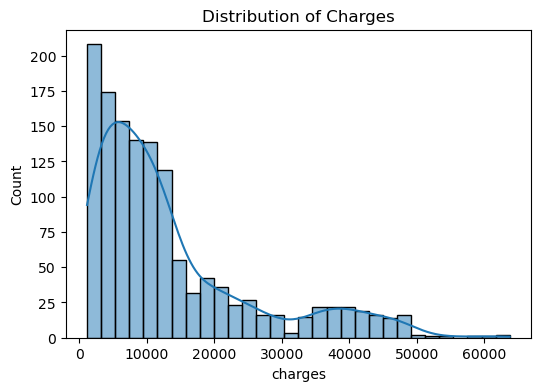

In [39]:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.savefig("charges_distribution.png")
plt.show()

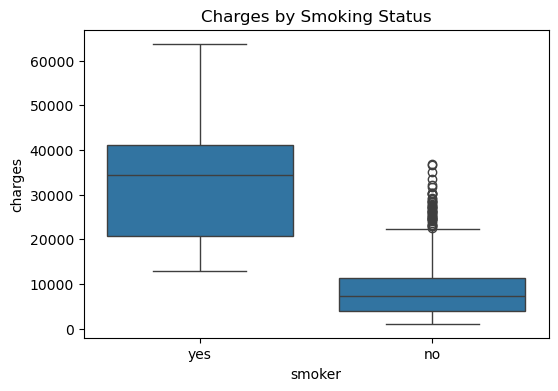

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.savefig("charges_by_smoker.png")
plt.show()

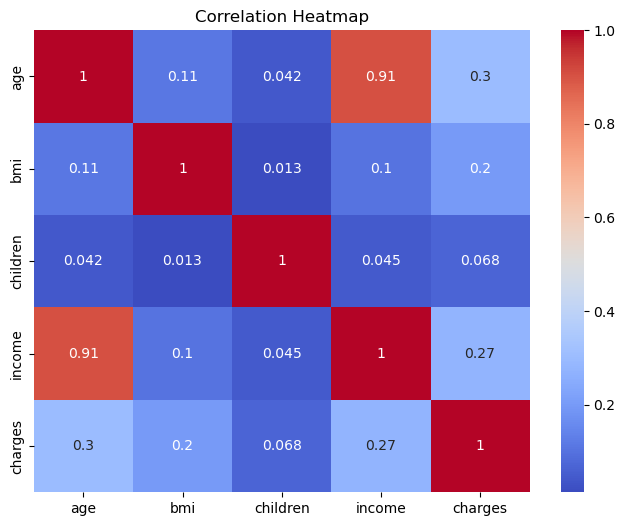

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

In [43]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])              # male=1, female=0
df['smoker'] = le.fit_transform(df['smoker'])         # yes=1, no=0
df['preexisting_condition'] = le.fit_transform(df['preexisting_condition'])

In [44]:
df = pd.get_dummies(df, columns=['region', 'insurance_plan'], drop_first=True)

In [45]:
df

,age,sex,bmi,children,smoker,income,preexisting_condition,charges,region_northwest,region_southeast,region_southwest,insurance_plan_Premium,insurance_plan_Standard
0,19,0,27.900,0,1,25173.71,0,16884.92400,False,False,True,False,True
1,18,1,33.770,1,0,18893.89,0,1725.55230,False,True,False,False,False
2,28,1,33.000,3,0,37181.51,0,4449.46200,False,True,False,False,True
3,33,1,22.705,0,0,50184.24,0,21984.47061,True,False,False,True,False
4,32,1,28.880,0,0,34926.77,0,3866.85520,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,70325.81,1,10600.54830,True,False,False,False,False
1334,18,0,31.920,0,0,21189.34,0,2205.98080,False,False,False,False,False
1335,18,0,36.850,0,0,17303.31,0,1629.83350,False,True,False,True,False
1336,21,0,25.800,0,0,18692.78,0,2007.94500,False,False,True,False,False


In [47]:
X = df.drop('charges', axis=1) # Independent
y = df['charges']# dependent
print(X)
print(y)

      age  sex     bmi  children  smoker    income  preexisting_condition  \
0      19    0  27.900         0       1  25173.71                      0   
1      18    1  33.770         1       0  18893.89                      0   
2      28    1  33.000         3       0  37181.51                      0   
3      33    1  22.705         0       0  50184.24                      0   
4      32    1  28.880         0       0  34926.77                      0   
...   ...  ...     ...       ...     ...       ...                    ...   
1333   50    1  30.970         3       0  70325.81                      1   
1334   18    0  31.920         0       0  21189.34                      0   
1335   18    0  36.850         0       0  17303.31                      0   
1336   21    0  25.800         0       0  18692.78                      0   
1337   61    0  29.070         0       1  69180.24                      0   

      region_northwest  region_southeast  region_southwest  \
0            

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1070, 12)
(268, 12)
(1070,)
(268,)


In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled)
print(X_test_scaled)

[[ 0.47222651 -1.0246016  -1.75652513 ... -0.5723141  -0.48828877
  -0.87336574]
 [ 0.54331294 -1.0246016  -1.03308239 ... -0.5723141  -0.48828877
  -0.87336574]
 [ 0.8987451  -1.0246016  -0.94368672 ... -0.5723141  -0.48828877
   1.14499569]
 ...
 [ 1.3252637   0.97598911 -0.89153925 ... -0.5723141  -0.48828877
  -0.87336574]
 [-0.16755139 -1.0246016   2.82086429 ...  1.74729228 -0.48828877
   1.14499569]
 [ 1.1120044   0.97598911 -0.10932713 ...  1.74729228 -0.48828877
   1.14499569]]
[[ 0.40114007 -1.0246016  -0.89153925 ... -0.5723141  -0.48828877
   1.14499569]
 [-0.23863782 -1.0246016  -0.08946143 ... -0.5723141  -0.48828877
  -0.87336574]
 [ 1.75178229 -1.0246016  -0.60845296 ... -0.5723141  -0.48828877
   1.14499569]
 ...
 [-0.09646495  0.97598911 -0.41972876 ... -0.5723141  -0.48828877
   1.14499569]
 [ 1.04091797 -1.0246016   2.78941026 ... -0.5723141   2.04796845
  -0.87336574]
 [ 0.82765867 -1.0246016   0.60252728 ...  1.74729228 -0.48828877
   1.14499569]]


In [54]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)


In [64]:
r2score=r2_score(y_test,lr_pred)
print(r2score)
lr_mae = mean_absolute_error(y_test, lr_pred)
print(lr_mae)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(lr_rmse)




0.7831219187789507
4186.135796690799
5802.589680301178


In [56]:
svr = SVR(kernel='rbf', C=1000, gamma=0.1)
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

In [65]:
r2score=r2_score(y_test,svr_pred)
print(r2score)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
print(svr_rmse)
svr_mae = mean_absolute_error(y_test, svr_pred)
print(svr_mae)

0.6028258969863816
7852.437562581904
3640.405862203841


In [58]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)   # RF doesn't need scaling
rf_pred = rf.predict(X_test)

In [66]:
r2score=r2_score(y_test,rf_pred)
print(r2score)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(rf_rmse)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(rf_mae)

0.8584005856839044
4688.617008516681
2750.9688669029856


In [67]:

print("Linear Regression")
print("R2 Score :", lr_r2)
print("RMSE     :", lr_rmse)
print("MAE      :", lr_mae)
print("\nSVR")
print("R2 Score :", svr_r2)
print("RMSE     :", svr_rmse)
print("MAE      :", svr_mae)
print("\nRandom Forest")
print("R2 Score :", rf_r2)
print("RMSE     :", rf_rmse)
print("MAE      :", rf_mae)

Linear Regression
R2 Score : 0.7831219187789507
RMSE     : 5802.589680301178
MAE      : 4186.135796690799

SVR
R2 Score : 0.6028258969863816
RMSE     : 7852.437562581904
MAE      : 3640.405862203841

Random Forest
R2 Score : 0.8584005856839044
RMSE     : 4688.617008516681
MAE      : 2750.9688669029856
